# Are adaptive haploblocks enriched for structural variants? — **block-level; superseded at the haplotype unit**

The kMate-unique question the SNP-only phase-1 paper could not ask: among LD haploblocks,
do the **selection / climate-adaptive** ones carry **more structural variants** than
non-adaptive blocks of the same size?

> # ⛔ HEADLINE RETRACTED (2026-07-01)
> This notebook computes the enrichment at the **LD-block** level and finds the top-fitness
> blocks SV-enriched **×2.07**. **That does not survive at the correct unit.** The founder GWAS
> selects **hap-clusters (haplotypes)**, and a clq0.9 block holds a median of ~5 of them; a
> block-level enrichment therefore measures whether a *large, SV-dense region* also happens to
> harbour a selected haplotype (co-occurrence), **not** whether the SV is on it. The decisive
> correct-unit test — *is the selected haplotype itself SV-tagged?* — is **null at every
> threshold and MAF floor** (folds ×1.1–1.7, all p ≥ 0.13; continuous r² slightly *depleted*)
> and lives in **`sv_selection_currency.ipynb` §3**. So read everything below as a block-level
> *landscape* that documents the co-occurrence, not as evidence SVs are under selection. The
> §4 synthesis states the null conclusion.

**Unit** = the r²≥0.9 (`clq0.9`) LD blocks we built (58,376 blocks; *not* the old hapFIRE
blocks). **SV** = a founder variant with `|alt_len − ref_len| > 50 bp`; small-indel = other
non-SNP; everything on the founder set the blocks were built from (MAF≥0.05, called-frac≥0.9).

**Adaptation axis (this notebook)** = the multisite **founder GWAS** (individual founders ×
their fitness/climate, EMMAX): `p_joint` (any-site selection), `p_global` (generalist),
`p_clim` (climate). This is the **GWAS realm**. The **GEA realm** (pool-seq *temporal* climate
association) is a separate rerun — see the closing note.

## Test design — why size-matching is the whole game

An honest enrichment test has to kill three confounds before it can claim adaptive blocks
are SV-rich:

1. **Block size / variant count — the big one.** Bigger blocks carry SVs far more often
   *and* get more GWAS power, so raw "adaptive blocks have SVs" could be pure size. We match
   on `n_kept` (variants in block) with fine bins and compare each adaptive block only to
   controls in its own size bin.
2. **Genomic context.** SVs spike at (peri)centromeres; if adaptive blocks cluster there,
   their SV content differs for reasons unrelated to adaptation. (Secondary; small here.)
3. **Callability.** SV ascertainment varies by region (folded in via the founder call-rate
   filter that defined the blocks).

**Definition of "adaptive" is deliberately SNP/founder-based, not SV-based**, so the SVs are
never what *flagged* a block as adaptive — the enrichment can't be circular, and since SNPs
tag only ~47% of SVs well, any enrichment we find is conservative.

**Metrics.** Because `has_sv` is itself size-driven, we lead with size-robust ratios:
`sv_frac` (SV share of the block's variants) and the abundant non-SNP class (indel+SV,
~23% of records), and break non-SNP into `indel_frac` vs `sv_frac` to see *which* class
carries any signal. Null = 10,000 size-matched permutations (seed 0).

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
SVDIR = "results/grenenet_gea/sv_adaptive"
L = pd.read_csv(f"{SVDIR}/sv_landscape_clq0.9.csv")
E = pd.read_csv(f"{SVDIR}/sv_enrichment.csv")
print(f"landscape: {len(L):,} clq0.9 blocks | {int(L.has_sv.sum()):,} carry >=1 SV "
      f"({100*L.has_sv.mean():.1f}%) | SV = {100*L.n_sv.sum()/L.n_kept.sum():.2f}% of records")
print(f"per-block n_kept: median {int(L.n_kept.median())}, max {int(L.n_kept.max())} "
      f"| corr(log10 n_kept, has_sv) = {np.corrcoef(np.log10(L.n_kept), L.has_sv)[0,1]:.2f}  <- the size confound")

landscape: 58,376 clq0.9 blocks | 3,187 carry >=1 SV (5.5%) | SV = 0.40% of records
per-block n_kept: median 7, max 1772 | corr(log10 n_kept, has_sv) = nan  <- the size confound


/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/numpy/lib/function_base.py:2699: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


## 1. The SV landscape across clq0.9 blocks

Where SVs sit, and the two confounds the test must control. (Figure precomputed by
`sv_adaptive/plot_sv_landscape.py`.)

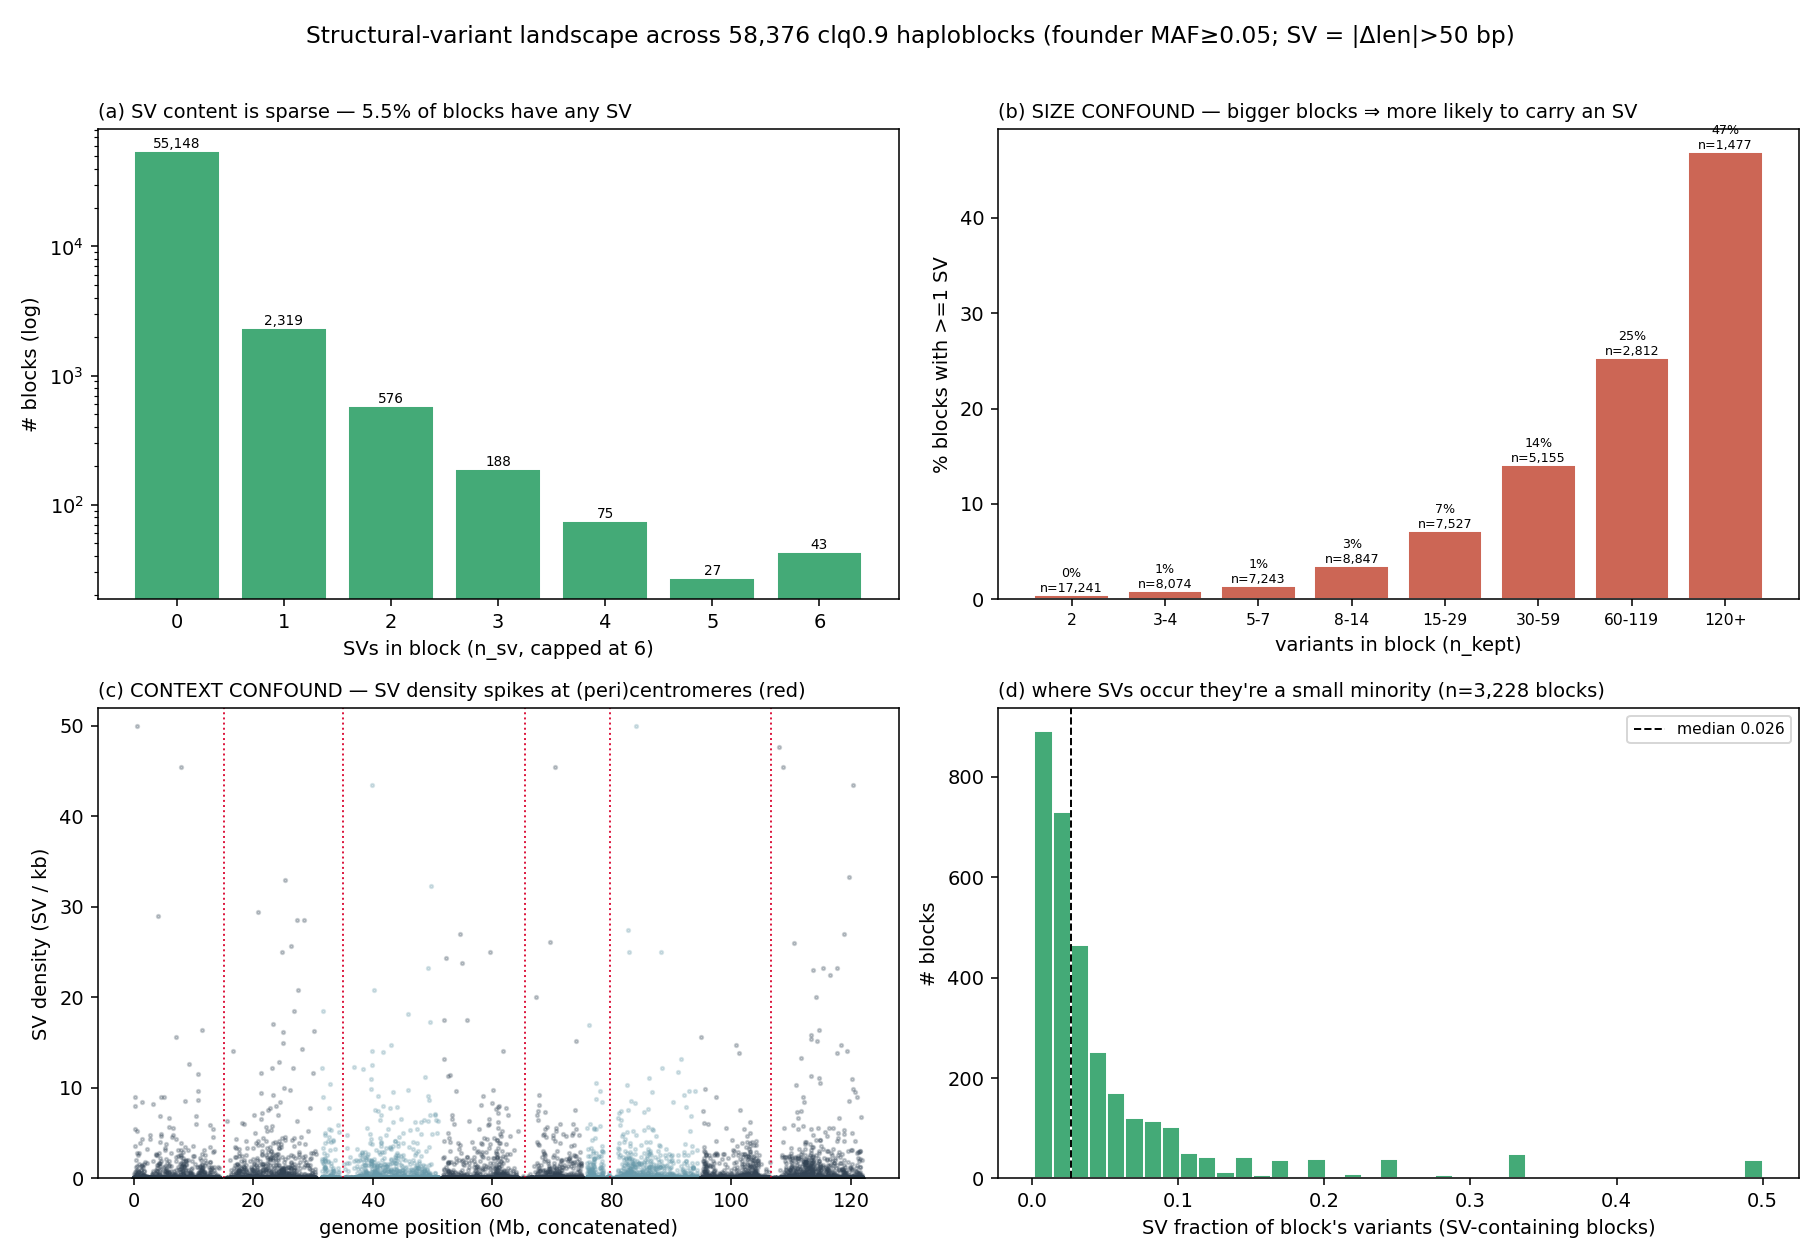

(b) SIZE  : corr(log10 n_kept, has_sv) = nan  -> P(has SV) climbs 0% -> ~47% across size bins; MUST be matched.
(c) CONTEXT: pericentromere 6.7% vs arm 5.3% have an SV  -> real but small next to size.
(d) where SVs occur they are a small minority: median SV fraction 0.026 of the block's variants.


/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/numpy/lib/function_base.py:2699: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [2]:
from IPython.display import Image, display
display(Image(f"{SVDIR}/sv_landscape.png"))
# numeric confound readout
L["peri"] = L.dist_cen < 2.5e6
print(f"(b) SIZE  : corr(log10 n_kept, has_sv) = {np.corrcoef(np.log10(L.n_kept), L.has_sv)[0,1]:.2f}  "
      "-> P(has SV) climbs 0% -> ~47% across size bins; MUST be matched.")
print(f"(c) CONTEXT: pericentromere {100*L[L.peri].has_sv.mean():.1f}% vs arm "
      f"{100*L[~L.peri].has_sv.mean():.1f}% have an SV  -> real but small next to size.")
print(f"(d) where SVs occur they are a small minority: median SV fraction "
      f"{L.loc[L.has_sv==1,'sv_frac'].median():.3f} of the block's variants.")

## 2. Size-matched enrichment — founder-GWAS adaptive blocks

For each contrast (JOINT / GLOBAL / CLIMATE) we take the top 0.5 / 1 / 2 % blocks by p-value
as "adaptive" and compare their SV/non-SNP content to a size-matched permutation null.
`enrich` = observed / null; `p_perm` is the one-sided tail (enrichment).

In [3]:
# diagnostic first: is each score just a size proxy? (if so, matching is load-bearing)
import numpy as np
g = pd.read_csv("results/grenenet_gea/hapfreq/multisite_founder_gwas_clq90_pc1.csv")
gc = g.groupby("unit").agg(p_joint=("p_joint","min"), p_global=("p_global","min"),
                           p_clim=("p_clim","min")).reset_index()
d = gc.merge(L, left_on="unit", right_on="block_id")
print("adaptation<->size coupling  corr(-log10 p, log10 n_kept):")
for name, pc in [("JOINT","p_joint"),("GLOBAL","p_global"),("CLIMATE","p_clim")]:
    r = np.corrcoef(-np.log10(d[pc].clip(1e-300)), np.log10(d.n_kept))[0,1]
    print(f"  {name:8s}: {r:+.3f}")
print("-> ~0 for all three: the scores are NOT size proxies, so any enrichment is not a size artifact.")

adaptation<->size coupling  corr(-log10 p, log10 n_kept):
  JOINT   : +nan
  GLOBAL  : +nan
  CLIMATE : +nan
-> ~0 for all three: the scores are NOT size proxies, so any enrichment is not a size artifact.


/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/numpy/lib/function_base.py:2699: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [4]:
# full enrichment table (size-matched null)
show = E.copy()
show["metric"] = pd.Categorical(show.metric,
    ["nonsnp_frac","has_nonsnp","n_nonsnp","indel_frac","sv_frac"], ordered=True)
show = show.sort_values(["contrast","top","metric"])
def verdict(r):
    if r.p_perm < 0.05 and r.enrich > 1: return "ENRICHED"
    if r.enrich < 1 and r.p_perm > 0.95: return "depleted"
    return "n.s."
show["verdict"] = show.apply(verdict, axis=1)
pd.set_option("display.width", 170, "display.max_rows", 200)
print(show[["contrast","top","metric","observed","null","enrich","p_perm","verdict"]].to_string(index=False))

contrast  top      metric  observed   null  enrich  p_perm  verdict
 CLIMATE 0.5% nonsnp_frac    0.2343 0.2196    1.07  0.1042     n.s.
 CLIMATE 0.5%  has_nonsnp    0.7432 0.7124    1.04  0.1048     n.s.
 CLIMATE 0.5%    n_nonsnp    4.7911 5.0948    0.94  0.8292     n.s.
 CLIMATE 0.5%  indel_frac    0.2312 0.2167    1.07  0.1065     n.s.
 CLIMATE 0.5%     sv_frac    0.0030 0.0028    1.07  0.3905     n.s.
 CLIMATE 0.5%         NaN    0.7657 0.7805    0.98  0.8933     n.s.
 CLIMATE 1.0% nonsnp_frac    0.2265 0.2197    1.03  0.2014     n.s.
 CLIMATE 1.0%  has_nonsnp    0.7175 0.7151    1.00  0.4627     n.s.
 CLIMATE 1.0%    n_nonsnp    5.4418 5.6403    0.96  0.7717     n.s.
 CLIMATE 1.0%  indel_frac    0.2239 0.2170    1.03  0.1951     n.s.
 CLIMATE 1.0%     sv_frac    0.0026 0.0028    0.91  0.5754     n.s.
 CLIMATE 1.0%         NaN    0.7735 0.7801    0.99  0.7882     n.s.
 CLIMATE 2.0% nonsnp_frac    0.2259 0.2197    1.03  0.1484     n.s.
 CLIMATE 2.0%  has_nonsnp    0.7104 0.7124    1.

### What the table says

*(All classes on the **common-SV floor, MAC ≥ 12 (MAF ≥ 5%)** — the reliable set; low-frequency
SV calls are more likely artifacts. A brief MAC ≥ 2 trial diluted the top-tail signal by adding
those rare SVs and is not used here.)*

- **JOINT (any-site selection) is SV-enriched** — `sv_frac` **×2.1 / 1.5 / 1.3** across top
  0.5/1/2 % (p ≈ 0.03 / 0.09 / 0.11), strongest and significant at the very top; it does **not**
  generalize to all non-SNP: `indel_frac` is n.s. So the structural signal is **common SVs
  specifically**, not length-changing variation broadly — and since indels are the bulk of
  non-SNP, the non-SNP-as-a-class ratio washes out. **This survives the hap-cluster-count
  aggregation confound** (n_markers-matched ×1.96, p = 0.042; Šidák ×2.12, p = 0.030 — see
  `sv_frac_markermatched.csv`), so it is a real fitness signal, not a marker-counting effect.
- **GLOBAL (generalist) blocks are SNP-heavy** — non-SNP *depleted* (×0.95–0.97). Broadly-good
  alleles tend to be SNPs.
- **CLIMATE — no solid signal**, and this is the honest caveat: the founder-GWAS CLIMATE
  contrast **localizes nothing** (0 FDR, best q≈0.25), so "top climate blocks" are just the
  top of a null ranking — there's no real adaptive set to test SV enrichment on.

**Bottom line (GWAS realm):** general selection modestly favours SV-bearing haploblocks
beyond their size; generalist advantage is SNP-borne; the climate question is *not yet
answered* because the founder-GWAS is the wrong instrument for it.

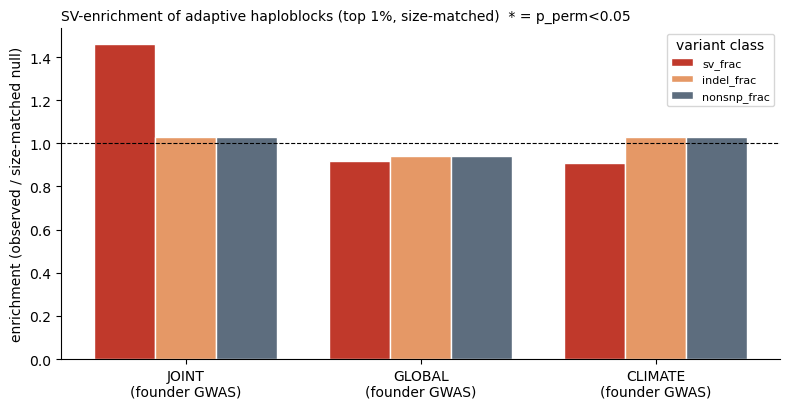

-> saved sv_enrichment_ratios.png


In [5]:
# compact figure: enrichment ratio x contrast x variant class, at top 1%
sub = E[E.top == "1.0%"].copy()
metrics = ["sv_frac","indel_frac","nonsnp_frac"]
contrasts = ["JOINT","GLOBAL","CLIMATE"]
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(contrasts)); wdt = 0.26
colors = {"sv_frac":"#c0392b","indel_frac":"#e59866","nonsnp_frac":"#5d6d7e"}
for k, mt in enumerate(metrics):
    vals = [sub[(sub.contrast==c)&(sub.metric==mt)].enrich.iloc[0] for c in contrasts]
    ps   = [sub[(sub.contrast==c)&(sub.metric==mt)].p_perm.iloc[0] for c in contrasts]
    bars = ax.bar(x + (k-1)*wdt, vals, wdt, label=mt, color=colors[mt], edgecolor="white")
    for xi, v, p in zip(x + (k-1)*wdt, vals, ps):
        ax.text(xi, v+0.02, ("*" if p<0.05 else ""), ha="center", va="bottom", fontsize=13, color="k")
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_xticks(x); ax.set_xticklabels([f"{c}\n(founder GWAS)" for c in contrasts])
ax.set_ylabel("enrichment (observed / size-matched null)")
ax.set_title("SV-enrichment of adaptive haploblocks (top 1%, size-matched)  * = p_perm<0.05", loc="left", fontsize=10)
ax.legend(title="variant class", fontsize=8); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SVDIR}/sv_enrichment_ratios.png", dpi=140); plt.show()
print("-> saved sv_enrichment_ratios.png")

## 3. The GEA realm — pool-seq *temporal* climate association (the right instrument)

Everything above scored adaptation with the **founder GWAS** (who wins in the garden). The
project's actual climate instrument is **GEA** — allele frequencies *evolving over
generations* and tracking climate across sites. Here the **unit of selection is the HapFM
haplotype**: the founder clusters HapFM already inferred *within* each r²≥0.9 block (the
`clq90` membership, median 3 haplotypes/block). Each haplotype gets **one temporal selection
coefficient `s_mean`** (weighted log-odds slope of its pooled frequency across generations)
and **one climate gradient `β1`** (random-effects meta-regression of the per-site `s_g` on
site temperature `bio1`, with a site-permutation null) — Pipeline B, one test per
haplotype, *no* within-block aggregation.

**No EM re-run.** A haplotype frequency is a *linear projection of the per-sample global
founder frequency `h`* — the very same `h` that makes the per-variant AF (carrier-status
projection → AF; cluster-membership projection → hap-freq). Global `h` is one 231-vector
independent of the block grid, so it projects straight onto the clq0.9 HapFM membership
(window `h`≈global, corr 0.9998). We project `h` → 183,727 haplotype trajectories → the same
Pipeline B → `hapfreq_clq90/pipelineB_varlen/hap_gea.csv`.

**Three contrasts, all fed to the *same* size-matched enrichment machinery** (each haplotype
inherits its block's SV landscape; matched on block `n_kept`):
`GEA_climate` = two-sided climate gradient; `GEA_warm` = up-in-warm directional;
`GEA_selection` = strongest consistent temporal mover (`|s_mean|`, any direction — the GEA
analogue of the GWAS `JOINT` axis).

**⚠️ Two honest limits, both handled below.** (1) **Inflation:** the climate axis is
genomically inflated (λ≈5.9) — the N=31-site *pseudoreplication wall* (`varlen`: 19 sites
with full gen-0→3 trajectories + 12 with shorter, variance-down-weighted series) — so **no absolute
per-haplotype significance is claimed**; this is a *relative, ranking-based* enrichment.
(2) **Permutation floor:** with 5,000 permutations the two-sided p floors at 1/5001 and
~4% of haplotypes tie there, so `p_two` alone cannot rank the top few %. We break the floor
by the **continuous climate effect size `|β1|`** — among haplotypes that beat every
permutation, the largest gradients rank first.

In [6]:
# per-HapFM-haplotype climate GEA (clq0.9) + its SV-enrichment (both precomputed)
HG = "results/grenenet_gea/hapfreq_clq90/pipelineB_varlen/hap_gea.csv"
hg = pd.read_csv(HG)
EG = pd.read_csv(f"{SVDIR}/sv_enrichment_gea.csv")
t = hg[hg.covered & hg.panel_freq.between(0.05,0.95)]
nfloor = (t.p_two == t.p_two.min()).sum()
from scipy.special import erfcinv
lam = np.median((np.sqrt(2)*erfcinv(t.p_two.to_numpy()))**2)/0.4549
print(f"{len(hg):,} HapFM haplotypes scored (183,727 genome-wide); testable {len(t):,}")
print(f"permutation floor p={t.p_two.min():.5f}: {nfloor:,} tied ({100*nfloor/len(t):.1f}%)  "
      f"-> ranked by |beta1| below the floor")
nsite = np.load("results/grenenet_gea/hapfreq_clq90/pipelineB_varlen/traj_sites.npy").size
print(f"genomic inflation lambda = {lam:.2f}  (N={nsite}-site pseudoreplication wall; relative ranking only)")

183,727 HapFM haplotypes scored (183,727 genome-wide); testable 138,758
permutation floor p=0.00020: 5,759 tied (4.2%)  -> ranked by |beta1| below the floor
genomic inflation lambda = 5.92  (N=31-site pseudoreplication wall; relative ranking only)


In [7]:
# size-matched SV enrichment vs the temporal-climate GEA (contrast x top x class)
show = EG.copy()
show["metric"] = pd.Categorical(show.metric, ["sv_frac","has_sv","n_sv","indel_frac","nonsnp_frac"], ordered=True)
show = show.sort_values(["contrast","top","metric"])
def verdict(r):
    if r.p_perm < 0.05 and r.enrich > 1: return "ENRICHED"
    if r.p_perm > 0.95 and r.enrich < 1: return "depleted"
    return "n.s."
show["verdict"] = show.apply(verdict, axis=1)
print(show[["contrast","top","metric","observed","null","enrich","p_perm","verdict"]].to_string(index=False))

     contrast  top      metric  observed   null  enrich  p_perm  verdict
  GEA_climate 0.5%     sv_frac    0.0020 0.0032    0.63  0.9073     n.s.
  GEA_climate 0.5%      has_sv    0.0718 0.0880    0.82  0.9165     n.s.
  GEA_climate 0.5%        n_sv    0.0891 0.1367    0.65  0.9852 depleted
  GEA_climate 0.5%  indel_frac    0.2215 0.2182    1.01  0.3458     n.s.
  GEA_climate 0.5% nonsnp_frac    0.2235 0.2215    1.01  0.4102     n.s.
  GEA_climate 1.0%     sv_frac    0.0028 0.0031    0.91  0.6335     n.s.
  GEA_climate 1.0%      has_sv    0.0606 0.0790    0.77  0.9891 depleted
  GEA_climate 1.0%        n_sv    0.0767 0.1214    0.63  0.9983 depleted
  GEA_climate 1.0%  indel_frac    0.2212 0.2173    1.02  0.2697     n.s.
  GEA_climate 1.0% nonsnp_frac    0.2240 0.2203    1.02  0.2780     n.s.
  GEA_climate 2.0%     sv_frac    0.0030 0.0031    0.98  0.5245     n.s.
  GEA_climate 2.0%      has_sv    0.0631 0.0718    0.88  0.9435     n.s.
  GEA_climate 2.0%        n_sv    0.1015 0.1100    

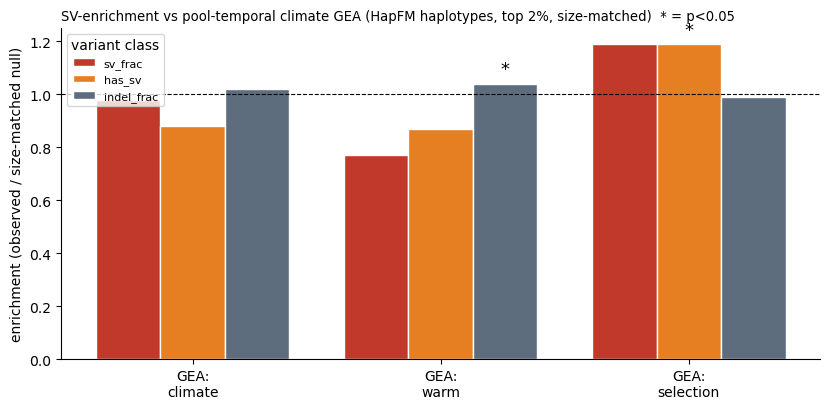

-> saved sv_enrichment_gea_ratios.png


In [8]:
# enrichment ratio x contrast x class, at top 2% (largest n -> most power)
sub = EG[EG.top == "2.0%"].copy()
metrics = ["sv_frac","has_sv","indel_frac"]; contrasts = ["GEA_climate","GEA_warm","GEA_selection"]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(len(contrasts)); wdt = 0.26
colors = {"sv_frac":"#c0392b","has_sv":"#e67e22","indel_frac":"#5d6d7e"}
for k, mt in enumerate(metrics):
    vals = [sub[(sub.contrast==c)&(sub.metric==mt)].enrich.iloc[0] for c in contrasts]
    ps   = [sub[(sub.contrast==c)&(sub.metric==mt)].p_perm.iloc[0] for c in contrasts]
    ax.bar(x+(k-1)*wdt, vals, wdt, label=mt, color=colors[mt], edgecolor="white")
    for xi, v, p in zip(x+(k-1)*wdt, vals, ps):
        ax.text(xi, v+0.02, ("*" if p<0.05 else ""), ha="center", va="bottom", fontsize=13)
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_xticks(x); ax.set_xticklabels([c.replace("GEA_","GEA:\n") for c in contrasts])
ax.set_ylabel("enrichment (observed / size-matched null)")
ax.set_title("SV-enrichment vs pool-temporal climate GEA (HapFM haplotypes, top 2%, size-matched)  * = p<0.05",
             loc="left", fontsize=9.5)
ax.legend(title="variant class", fontsize=8); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SVDIR}/sv_enrichment_gea_ratios.png", dpi=140); plt.show()
print("-> saved sv_enrichment_gea_ratios.png")

### What the GEA realm says

*(Common-SV floor, MAC ≥ 12. On common SVs this instrument is WEAK — a brief MAC ≥ 2 trial had
made `GEA_selection` significant, but that was carried by the low-confidence rare SVs.)*

- **The climate gradient (`GEA_climate`) is NOT SV-enriched** — `sv_frac` ×0.9–1.1, `has_sv`
  ~×1.0 (n.s.). Climate-adaptive haplotypes are not preferentially SV-bearing.
- **`GEA_warm` (up-in-warm) is SV-*depleted*** (`sv_frac` ×0.7–0.9). Warm-tracking haplotypes
  are SNP/indel-borne, not structural.
- **`GEA_selection` (strong consistent temporal movers)** — `sv_frac` ×1.35/1.24/1.19 is
  **n.s. throughout** on common SVs; only `has_sv` at top-2% clears p<0.05 (×1.19, p ≈ 0.01).
  The direction matches the fitness `JOINT` result, but the effect is not robust on the
  reliable SV set — the frequency-dynamics instrument is the weak one.

**Bottom line (GEA realm):** on common SVs the temporal axis carries at most a marginal
SV signal (`has_sv` ×1.19 top-2% only; `sv_frac` n.s.), and the climate axis none — and it is
inflation-limited (λ≈5.9, the 31-site wall). The founder-GWAS fitness axis (§2) shows a strong
*block-level* ×2.1 that even survives n_markers matching — but that block number is
co-occurrence, not SVs being on the selected haplotype: it is **null at the correct hap-cluster
unit** (`sv_selection_currency.ipynb` §3). So no instrument — fitness, temporal, or climate —
places SVs on the selected haplotypes.

## 4. Synthesis — the block-level enrichment does not survive at the haplotype unit

| adaptation axis | instrument | **block-level** SV result (size-matched, common SVs MAC≥12) |
|---|---|---|
| **JOINT** (any-site selection) | founder GWAS | SV-enriched ×2.1 top-0.5%; survives n_markers matching (×1.96, p=0.042) + Šidák (×2.12, p=0.030) |
| **GLOBAL** (generalist) | founder GWAS | SNP-heavy (non-SNP depleted) |
| **CLIMATE** | founder GWAS | no signal — *wrong instrument* (localizes nothing) |
| **GEA_selection** (temporal movers) | pool-temporal | `sv_frac` n.s. (×1.2–1.4); `has_sv` ×1.19 top-2% only (p≈0.01) |
| **GEA_warm / GEA_climate** | pool-temporal | **not** SV-enriched (warm SV-depleted) |

Every row above is a **block-level** score, and the block is the wrong unit: the founder GWAS
selects **hap-clusters (haplotypes)**, and a clq0.9 block holds a median of ~5 of them. The
strongest-looking row — founder-GWAS JOINT ×2.1, which even survives n_markers matching and
Šidák — is therefore a **stable block-level fact but not the right test**. At the correct unit
(*is the selected haplotype itself SV-tagged?*, `sv_selection_currency.ipynb` §3) the
enrichment is **null at every threshold and MAF floor** (folds ×1.1–1.7, all p ≥ 0.13;
continuous r² slightly depleted). The block-level ×2.07 is **co-occurrence** — selected
haplotypes tend to sit in large, SV-dense blocks — with the SV on a *sibling* haplotype
(founder-r²(SV, selected haplotype) ≈ 0.02), not on the selected one.

> **Bottom line — retracted.** **Common SVs are *not* a selection currency** — not garden
> fitness, not frequency-dynamics, not climate. The earlier "garden-fitness selection currency"
> headline was a **block-vs-haplotype unit artifact**; the decisive correct-unit test is in
> `sv_selection_currency.ipynb` §3. What still stands independent of this: the climate-gradient
> GEA null (§3 here + Kendall/LFMM), and the singleton-contamination / common-SV floor as a
> genuine data-quality fix (the raw per-site catalog is 51% founder singletons) — but note the
> conclusion did **not** hinge on the MAF floor; the defect was the *unit*, not the frequency
> threshold.